In [ ]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not enabled! Go to Runtime → Change runtime type → GPU")

PyTorch version: 2.8.0+cu126
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("\nYour Google Drive contents:")
!ls '/content/drive/MyDrive/'

print("\nChecking for MLB data...")
!ls '/content/drive/MyDrive/segmented_videos/'

!wc -l '/content/drive/MyDrive/segmented_videos/metadata.csv'
!ls '/content/drive/MyDrive/segmented_videos/' | head -20

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Your Google Drive contents:
 cleaned-gpo-ai-data-csv.csv	       mlb_results
'Colab Notebooks'		      'MSAI 349 - Machine Learning.gdoc'
'Communication Week 2'		      'Project Experiment Results.gdoc'
'Data Science Project Proposal.gdoc'   segmented_videos
 HW4.gdoc			      'Untitled document.gdoc'
 mlb_models

Checking for MLB data...
00R2EWIHPHZV.mp4  8MUU1AJOKXQP.mp4  HUZHUPOWMOAK.mp4  QECQ3O451JJS.mp4
00ULB0SE7OWT.mp4  8N4VO7H8TBVR.mp4  HV6PHVTNQKJZ.mp4  QFPZ0K9NW4PF.mp4
00XR9PTEMMYT.mp4  8O4Z9J7VCURS.mp4  HVRIQ1I902GJ.mp4  QFU6BRFXWCIM.mp4
011WMN7FXKWE.mp4  8O63P7TM3UB1.mp4  HWCXY4TNTK8Z.mp4  QHI2Y82YTZFX.mp4
01OC7YUS52QB.mp4  8Y6ZE12OHNF6.mp4  HWVCSPJ0I8OH.mp4  QLVJ3MYV8CGE.mp4
01YU5P4PFWUV.mp4  8ZFMYS6NJNSL.mp4  HZAFDFE5INSB.mp4  QPE56WBSLL4A.mp4
042VO7A7LTR9.mp4  918ZEWQPBU2I.mp4  I19WH9ILAYQ0.mp4  QQGPUMP1SI2J.mp4
044DXEZHB3IT.mp4  91YTHXRNHIJH.mp4  

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import cv2
import numpy as np
import pandas as pd
from torchvision import transforms, models
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import json
from pathlib import Path
import os

CONFIG = {
    'data_dir': '/content/drive/MyDrive/segmented_videos',
    'metadata_file': '/content/drive/MyDrive/segmented_videos/metadata.csv',
    'model_save_dir': '/content/drive/MyDrive/mlb_models',
    'results_dir': '/content/drive/MyDrive/mlb_results',
    'target_frames': 16,
    'img_size': (224, 224),
    'hidden_dim': 256,
    'num_layers': 2,
    'dropout': 0.5,
    'batch_size': 8,
    'num_epochs': 25,
    'learning_rate': 0.0001,
    'weight_decay': 1e-4,
    'train_split': 0.7,
    'val_split': 0.15,
    'test_split': 0.15,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

os.makedirs(CONFIG['model_save_dir'], exist_ok=True)
os.makedirs(CONFIG['results_dir'], exist_ok=True)

print(f"Device: {CONFIG['device']}")
print(f"Data directory: {CONFIG['data_dir']}")
print(f"Configuration loaded!")

Device: cuda
Data directory: /content/drive/MyDrive/segmented_videos
Configuration loaded!


In [ ]:
class VideoFrameExtractor:
    def __init__(self, target_frames=16, img_size=(224, 224)):
        self.target_frames = target_frames
        self.img_size = img_size

    def extract_frames(self, video_path):
        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            return None

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames == 0:
            cap.release()
            return None

        frame_indices = np.linspace(0, total_frames - 1,
                                   min(self.target_frames, total_frames),
                                   dtype=int)

        frames = []
        for idx in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, self.img_size)
                frames.append(frame)

        cap.release()

        while len(frames) < self.target_frames:
            if frames:
                frames.append(frames[-1])
            else:
                frames.append(np.zeros((*self.img_size, 3), dtype=np.uint8))

        return np.array(frames[:self.target_frames])

class MLBPitchDataset(Dataset):
    def __init__(self, video_dir, metadata_df, extractor, augment=True):
        self.video_dir = Path(video_dir)
        self.metadata = metadata_df
        self.extractor = extractor
        self.augment = augment

        valid_pitches = ['FF', 'CU', 'SL', 'CH', 'SI', 'FC', 'FT', 'KC', 'FS', 'knucklecurve']
        self.metadata = self.metadata[self.metadata['pitch_type'].isin(valid_pitches)]

        pitch_counts = self.metadata['pitch_type'].value_counts()
        valid_pitches_with_data = pitch_counts[pitch_counts >= 20].index.tolist()
        self.metadata = self.metadata[self.metadata['pitch_type'].isin(valid_pitches_with_data)]

        self.pitch_types = sorted(self.metadata['pitch_type'].unique())
        self.label_map = {pt: i for i, pt in enumerate(self.pitch_types)}

        print(f"\nDataset: {len(self.metadata)} clips, {len(self.pitch_types)} types")
        print(f"Types: {self.pitch_types}")

        if augment:
            self.transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.RandomHorizontalFlip(p=0.3),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
                transforms.RandomRotation(5),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
            ])

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        video_path = self.video_dir / row['filename']

        frames = self.extractor.extract_frames(video_path)
        if frames is None:
            frames = np.zeros((self.extractor.target_frames,
                             *self.extractor.img_size, 3), dtype=np.uint8)

        transformed_frames = [self.transform(frame) for frame in frames]
        video_tensor = torch.stack(transformed_frames)
        label = self.label_map[row['pitch_type']]

        return video_tensor, label

print("Dataset classes defined")

Dataset classes defined


In [30]:
class PitchClassifierCNNLSTM(nn.Module):
    def __init__(self, num_classes, hidden_dim=256, num_layers=2, dropout=0.5):
        super().__init__()

        resnet = models.resnet18(pretrained=True)
        self.cnn = nn.Sequential(*list(resnet.children())[:-1])
        cnn_out_dim = 512

        self.lstm = nn.LSTM(
            input_size=cnn_out_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        batch_size, frames, c, h, w = x.shape

        x = x.view(batch_size * frames, c, h, w)
        cnn_features = self.cnn(x)
        cnn_features = cnn_features.view(batch_size, frames, -1)

        lstm_out, (hn, cn) = self.lstm(cnn_features)
        final_hidden = hn[-1]

        logits = self.classifier(final_hidden)
        return logits

print("Model architecture defined")

Model architecture defined


In [22]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for videos, labels in tqdm(dataloader, desc="Training", leave=False):
        videos, labels = videos.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(dataloader), 100. * correct / total

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for videos, labels in tqdm(dataloader, desc="Validating", leave=False):
            videos, labels = videos.to(device), labels.to(device)
            outputs = model(videos)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(dataloader), 100. * correct / total

print("Training functions defined")

Training functions defined


In [ ]:
print("Loading metadata...")
metadata = pd.read_csv(CONFIG['metadata_file'])
print(f"✓ Loaded {len(metadata)} clips")

extractor = VideoFrameExtractor(
    target_frames=CONFIG['target_frames'],
    img_size=CONFIG['img_size']
)

full_dataset = MLBPitchDataset(
    video_dir=CONFIG['data_dir'],
    metadata_df=metadata,
    extractor=extractor,
    augment=True
)

total_size = len(full_dataset)
train_size = int(CONFIG['train_split'] * total_size)
val_size = int(CONFIG['val_split'] * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                         shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'],
                       shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'],
                        shuffle=False, num_workers=2)

print(f"\nData split:")
print(f"  Train: {len(train_dataset)}")
print(f"  Val: {len(val_dataset)}")
print(f"  Test: {len(test_dataset)}")

Loading metadata...
✓ Loaded 599 clips

Dataset: 599 clips, 6 types
Types: ['CH', 'CU', 'FF', 'SI', 'SL', 'knucklecurve']

✓ Data split:
  Train: 419
  Val: 89
  Test: 91


In [ ]:
num_classes = len(full_dataset.pitch_types)
model = PitchClassifierCNNLSTM(
    num_classes=num_classes,
    hidden_dim=CONFIG['hidden_dim'],
    num_layers=CONFIG['num_layers'],
    dropout=CONFIG['dropout']
)

device = torch.device(CONFIG['device'])
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),
                      lr=CONFIG['learning_rate'],
                      weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=5, factor=0.5
)

print(f"Model on {device}")
print(f"Number of classes: {num_classes}")
print(f"Classes: {full_dataset.pitch_types}")
print("\nModel ready to train!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 238MB/s]


✓ Model on cuda
✓ Number of classes: 6
✓ Classes: ['CH', 'CU', 'FF', 'SI', 'SL', 'knucklecurve']

Model ready to train!


In [ ]:
best_val_acc = 0
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print(f"\nStarting training for {CONFIG['num_epochs']} epochs...")
print("="*60)

for epoch in tqdm(range(CONFIG['num_epochs']), desc="Overall Progress"):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{CONFIG['num_epochs']}")
    print('='*60)

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    scheduler.step(val_acc)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'class_names': full_dataset.pitch_types,
            'label_map': full_dataset.label_map
        }, os.path.join(CONFIG['model_save_dir'], 'best_model.pth'))
        print(f"✓ New best model saved! (Val Acc: {val_acc:.2f}%)")

    print(f"Best Val Acc so far: {best_val_acc:.2f}%")

print("\n" + "="*60)
print("TRAINING COMPLETE!")
print(f"Best validation accuracy: {best_val_acc:.2f}%")
print("="*60)


Starting training for 25 epochs...


Overall Progress:   0%|          | 0/25 [00:00<?, ?it/s]


Epoch 1/25


Training:   0%|          | 0/53 [00:00<?, ?it/s]

Validating:   0%|          | 0/12 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/12 [00:00<?, ?it/s]

Train Loss: 0.3625, Train Acc: 88.78%
Val Loss: 1.8225, Val Acc: 56.18%
Best Val Acc so far: 65.17%

Epoch 25/25


Training:   0%|          | 0/53 [00:00<?, ?it/s]

Validating:   0%|          | 0/12 [00:00<?, ?it/s]

Train Loss: 0.2470, Train Acc: 91.65%
Val Loss: 1.8632, Val Acc: 56.18%
Best Val Acc so far: 65.17%

TRAINING COMPLETE!
Best validation accuracy: 65.17%


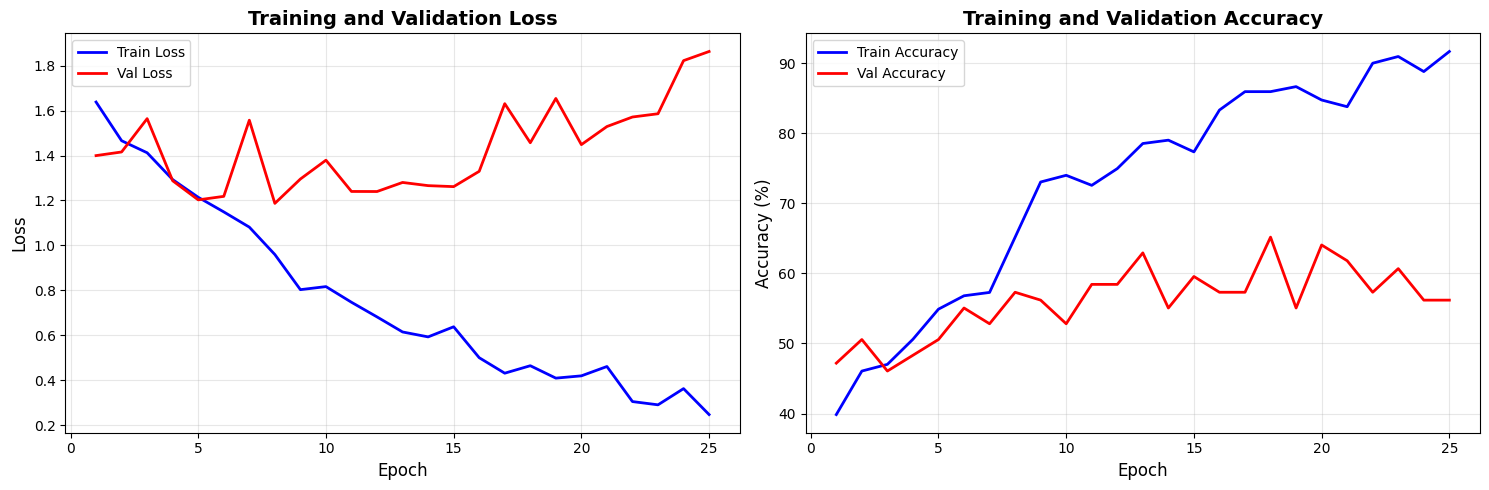

✓ Training curves saved!


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

epochs = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
ax1.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
ax2.plot(epochs, history['val_acc'], 'r-', label='Val Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'training_history.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training curves saved!")

Loading best model...
Testing on held-out test set...


Testing:   0%|          | 0/12 [00:00<?, ?it/s]


CLASSIFICATION REPORT
              precision    recall  f1-score   support

          CH       0.00      0.00      0.00         6
          CU       0.43      0.43      0.43         7
          FF       0.60      0.78      0.68        41
          SI       0.11      0.14      0.12         7
          SL       0.93      0.57      0.70        23
knucklecurve       0.25      0.29      0.27         7

    accuracy                           0.56        91
   macro avg       0.39      0.37      0.37        91
weighted avg       0.57      0.56      0.55        91



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


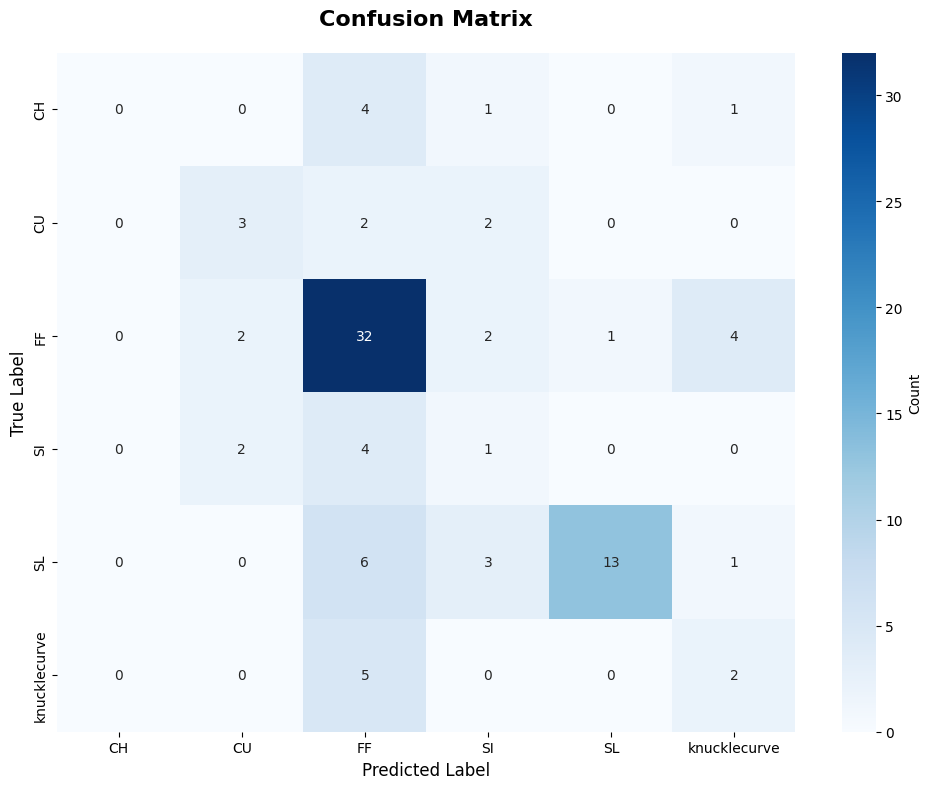


✓ Best validation accuracy: 65.17%
✓ Results saved to Google Drive: /content/drive/MyDrive/mlb_results


In [ ]:
print("Loading best model...")
checkpoint = torch.load(os.path.join(CONFIG['model_save_dir'], 'best_model.pth'))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("Testing on held-out test set...")
all_preds = []
all_labels = []

with torch.no_grad():
    for videos, labels in tqdm(test_loader, desc="Testing"):
        videos = videos.to(device)
        outputs = model(videos)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(all_labels, all_preds,
                          target_names=full_dataset.pitch_types))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset.pitch_types,
            yticklabels=full_dataset.pitch_types,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Best validation accuracy: {checkpoint['val_acc']:.2f}%")
print(f"✓ Results saved to Google Drive: {CONFIG['results_dir']}")

In [ ]:
print("Creating results package...")

import json

results_summary = {
    'best_val_accuracy': float(best_val_acc),
    'num_epochs': CONFIG['num_epochs'],
    'num_classes': num_classes,
    'classes': full_dataset.pitch_types,
    'dataset_size': {
        'train': len(train_dataset),
        'val': len(val_dataset),
        'test': len(test_dataset)
    },
    'final_metrics': {
        'train_acc': float(history['train_acc'][-1]),
        'val_acc': float(history['val_acc'][-1])
    }
}

with open(os.path.join(CONFIG['results_dir'], 'results_summary.json'), 'w') as f:
    json.dump(results_summary, f, indent=2)

print("Results summary saved!")
print("\n" + "="*60)
print("ALL FILES SAVED TO GOOGLE DRIVE:")
print("="*60)
print(f"📁 Location: MyDrive/mlb_models/ and MyDrive/mlb_results/")
print("\nFiles created:")
print("best_model.pth (trained model)")
print("training_history.png (learning curves)")
print("confusion_matrix.png (classification results)")
print("results_summary.json (metrics)")
print("\nYou can download these from Google Drive or access them anytime!")

Creating results package...
✓ Results summary saved!

ALL FILES SAVED TO GOOGLE DRIVE:
📁 Location: MyDrive/mlb_models/ and MyDrive/mlb_results/

Files created:
  ✓ best_model.pth (trained model)
  ✓ training_history.png (learning curves)
  ✓ confusion_matrix.png (classification results)
  ✓ results_summary.json (metrics)

You can download these from Google Drive or access them anytime!


# **Trying to redo the training with resnet 18 and with a more balanced dataset**

In [39]:
# ============================================================================
# ANALYZE CLASS DISTRIBUTION - DECIDE ON BALANCING STRATEGY
# ============================================================================

from collections import Counter, defaultdict
import random
from torch.utils.data import Subset

print("Loading metadata...")
metadata = pd.read_csv(CONFIG['metadata_file'])
print(f"✓ Loaded {len(metadata)} clips")

extractor = VideoFrameExtractor(
    target_frames=CONFIG['target_frames'],
    img_size=CONFIG['img_size']
)

full_dataset = MLBPitchDataset(
    video_dir=CONFIG['data_dir'],
    metadata_df=metadata,
    extractor=extractor,
    augment=True
)

print("=" * 60)
print("ANALYZING CLASS DISTRIBUTION")
print("=" * 60)

# Get labels directly from metadata (FAST - no video loading!)
all_labels = [full_dataset.label_map[pitch_type] for pitch_type in metadata['pitch_type']]
label_counts = Counter(all_labels)

print("\nCurrent class distribution:")
print("-" * 60)
for label, count in sorted(label_counts.items()):
    pct = (count / len(all_labels)) * 100
    print(f"  {full_dataset.pitch_types[label]:8s}: {count:5d} samples ({pct:5.2f}%)")

print("-" * 60)
print(f"Total samples: {len(all_labels)}")

# Calculate different target options
counts = list(label_counts.values())
min_count = min(counts)
max_count = max(counts)
median_count = int(np.median(counts))
mean_count = int(np.mean(counts))

print("\n" + "=" * 60)
print("BALANCING OPTIONS")
print("=" * 60)

print(f"\nOption 1 - MINIMUM ({min_count}):")
print(f"  → Undersample all classes to {min_count}")
print(f"  → Final dataset size: {min_count * len(label_counts)} samples")
print(f"  → Pros: No duplicates, no overfitting risk")
print(f"  → Cons: Lose a LOT of data")

print(f"\nOption 2 - MEDIAN ({median_count}):")
print(f"  → Balance all classes to {median_count}")
print(f"  → Final dataset size: {median_count * len(label_counts)} samples")
print(f"  → Pros: Balanced approach, reasonable data retention")
print(f"  → Cons: Some oversampling, some undersampling")

print(f"\nOption 3 - MEAN ({mean_count}):")
print(f"  → Balance all classes to {mean_count}")
print(f"  → Final dataset size: {mean_count * len(label_counts)} samples")
print(f"  → Pros: Keeps more data")
print(f"  → Cons: More oversampling for minorities")

print(f"\nOption 4 - MAXIMUM ({max_count}):")
print(f"  → Oversample all classes to {max_count}")
print(f"  → Final dataset size: {max_count * len(label_counts)} samples")
print(f"  → Pros: Keep ALL original data")
print(f"  → Cons: HEAVY oversampling → overfitting risk")

Loading metadata...
✓ Loaded 1157 clips

Dataset: 1157 clips, 6 types
Types: ['CH', 'CU', 'FF', 'SI', 'SL', 'knucklecurve']
ANALYZING CLASS DISTRIBUTION

Current class distribution:
------------------------------------------------------------
  CH      :   142 samples (12.27%)
  CU      :   168 samples (14.52%)
  FF      :   277 samples (23.94%)
  SI      :   126 samples (10.89%)
  SL      :   219 samples (18.93%)
  knucklecurve:   225 samples (19.45%)
------------------------------------------------------------
Total samples: 1157

BALANCING OPTIONS

Option 1 - MINIMUM (126):
  → Undersample all classes to 126
  → Final dataset size: 756 samples
  → Pros: No duplicates, no overfitting risk
  → Cons: Lose a LOT of data

Option 2 - MEDIAN (193):
  → Balance all classes to 193
  → Final dataset size: 1158 samples
  → Pros: Balanced approach, reasonable data retention
  → Cons: Some oversampling, some undersampling

Option 3 - MEAN (192):
  → Balance all classes to 192
  → Final dataset s

In [40]:
# ============================================================================
# ENHANCED DATA AUGMENTATION FOR MINORITY CLASSES
# ============================================================================

from torchvision import transforms
import torch

print("=" * 60)
print("CREATING DATASET WITH ENHANCED AUGMENTATION")
print("=" * 60)

class VideoFrameExtractorV2:
    def __init__(self, target_frames=16, img_size=(224, 224)):
        self.target_frames = target_frames
        self.img_size = img_size

    def extract_frames(self, video_path):
        import cv2
        import numpy as np

        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            return None

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames == 0:
            cap.release()
            return None

        frame_indices = np.linspace(0, total_frames - 1,
                                   min(self.target_frames, total_frames),
                                   dtype=int)

        frames = []
        for idx in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(frame, self.img_size)
                frames.append(frame)

        cap.release()

        while len(frames) < self.target_frames:
            if frames:
                frames.append(frames[-1])
            else:
                frames.append(np.zeros((*self.img_size, 3), dtype=np.uint8))

        return np.array(frames[:self.target_frames])

class MLBPitchDatasetV2(torch.utils.data.Dataset):
    def __init__(self, video_dir, metadata_df, extractor, augment=True):
        self.video_dir = Path(video_dir)
        self.metadata = metadata_df
        self.extractor = extractor
        self.augment = augment

        # Get unique pitch types
        self.pitch_types = sorted(metadata_df['pitch_type'].unique())
        self.label_map = {pt: i for i, pt in enumerate(self.pitch_types)}

        print(f"\nDataset: {len(self.metadata)} clips, {len(self.pitch_types)} types")
        print(f"Types: {self.pitch_types}")

        # Standard augmentation (for majority classes)
        self.standard_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomHorizontalFlip(p=0.3),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.RandomRotation(5),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

        # STRONG augmentation (for minority classes: CH, CU, SI, knucklecurve)
        self.strong_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomHorizontalFlip(p=0.5),  # Increased from 0.3
            transforms.RandomVerticalFlip(p=0.3),    # NEW - vertical flip
            transforms.ColorJitter(brightness=0.4, contrast=0.4,  # Increased from 0.2
                                 saturation=0.3, hue=0.1),  # NEW - saturation & hue
            transforms.RandomRotation(10),  # Increased from 5
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # NEW - translation
            transforms.RandomPerspective(distortion_scale=0.2, p=0.3),  # NEW - perspective
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

        # No augmentation (for validation/test)
        self.no_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

        # Define minority classes (including knucklecurve)
        self.minority_classes = ['CH', 'CU', 'SI', 'knucklecurve']

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        video_path = self.video_dir / row['filename']

        frames = self.extractor.extract_frames(video_path)
        if frames is None:
            frames = np.zeros((self.extractor.target_frames,
                             *self.extractor.img_size, 3), dtype=np.uint8)

        # Choose transform based on pitch type and augment flag
        pitch_type = row['pitch_type']
        if not self.augment:
            transform = self.no_transform
        elif pitch_type in self.minority_classes:
            transform = self.strong_transform  # Strong augmentation for minority
        else:
            transform = self.standard_transform  # Standard for majority

        transformed_frames = [transform(frame) for frame in frames]
        video_tensor = torch.stack(transformed_frames)
        label = self.label_map[pitch_type]

        return video_tensor, label

# Create new dataset with enhanced augmentation
print("\nCreating enhanced dataset...")
extractor_v2 = VideoFrameExtractorV2(
    target_frames=CONFIG['target_frames'],
    img_size=CONFIG['img_size']
)

full_dataset_v2 = MLBPitchDatasetV2(
    video_dir=CONFIG['data_dir'],
    metadata_df=metadata,
    extractor=extractor_v2,
    augment=True  # Will use strong augmentation for minority classes
)

print("\n✓ Enhanced dataset created with class-specific augmentation!")
print("  - Minority classes (CH, CU, SI, knucklecurve): STRONG augmentation")
print("  - Majority classes (FF, SL): STANDARD augmentation")

CREATING DATASET WITH ENHANCED AUGMENTATION

Creating enhanced dataset...

Dataset: 1157 clips, 6 types
Types: ['CH', 'CU', 'FF', 'SI', 'SL', 'knucklecurve']

✓ Enhanced dataset created with class-specific augmentation!
  - Minority classes (CH, CU, SI, knucklecurve): STRONG augmentation
  - Majority classes (FF, SL): STANDARD augmentation


In [41]:
# ============================================================================
# BALANCED SAMPLING V2 (100 samples per class)
# ============================================================================

from collections import Counter, defaultdict
import random
from torch.utils.data import Subset

print("=" * 60)
print("CREATING BALANCED DATASET V2")
print("=" * 60)

# Get labels from metadata (fast - no video loading)
all_labels_v2 = [full_dataset_v2.label_map[pitch_type] for pitch_type in metadata['pitch_type']]
label_counts_v2 = Counter(all_labels_v2)

print("\nOriginal class distribution:")
for label, count in sorted(label_counts_v2.items()):
    pct = (count / len(all_labels_v2)) * 100
    print(f"  {full_dataset_v2.pitch_types[label]:12s}: {count:3d} ({pct:5.2f}%)")

# Target: 100 samples per class
target_count_v2 = 100
print(f"\nTarget samples per class: {target_count_v2}")

# Group indices by class
class_indices_v2 = defaultdict(list)
for idx in range(len(full_dataset_v2)):
    label = full_dataset_v2.label_map[metadata.iloc[idx]['pitch_type']]
    class_indices_v2[label].append(idx)

# Balance each class
balanced_indices_v2 = []
minority_classes_v2 = ['CH', 'CU', 'SI', 'knucklecurve']

for label, indices in class_indices_v2.items():
    original_count = len(indices)
    pitch_type_name = full_dataset_v2.pitch_types[label]

    if len(indices) >= target_count_v2:
        # Undersample
        balanced_indices_v2.extend(random.sample(indices, target_count_v2))
        print(f"  {pitch_type_name:12s}: {original_count:3d} → {target_count_v2} (undersampled)")
    else:
        # Oversample
        balanced_indices_v2.extend(indices)
        num_to_add = target_count_v2 - len(indices)
        balanced_indices_v2.extend(random.choices(indices, k=num_to_add))

        # Mark as minority class
        minority_tag = " [MINORITY]" if pitch_type_name in minority_classes_v2 else ""
        print(f"  {pitch_type_name:12s}: {original_count:3d} → {target_count_v2} (oversampled +{num_to_add}){minority_tag}")

random.shuffle(balanced_indices_v2)

# Create balanced dataset
balanced_dataset_v2 = Subset(full_dataset_v2, balanced_indices_v2)
print(f"\n✓ Balanced dataset V2: {len(balanced_indices_v2)} total samples")

# Create splits
total_size_v2 = len(balanced_dataset_v2)
train_size_v2 = int(CONFIG['train_split'] * total_size_v2)
val_size_v2 = int(CONFIG['val_split'] * total_size_v2)
test_size_v2 = total_size_v2 - train_size_v2 - val_size_v2

train_dataset_v2, val_dataset_v2, test_dataset_v2 = random_split(
    balanced_dataset_v2, [train_size_v2, val_size_v2, test_size_v2],
    generator=torch.Generator().manual_seed(42)
)

# Create DataLoaders
train_loader_v2 = DataLoader(train_dataset_v2, batch_size=CONFIG['batch_size'],
                         shuffle=True, num_workers=2)
val_loader_v2 = DataLoader(val_dataset_v2, batch_size=CONFIG['batch_size'],
                       shuffle=False, num_workers=2)
test_loader_v2 = DataLoader(test_dataset_v2, batch_size=CONFIG['batch_size'],
                        shuffle=False, num_workers=2)

print(f"\nData split:")
print(f"  Train: {len(train_dataset_v2)}")
print(f"  Val:   {len(val_dataset_v2)}")
print(f"  Test:  {len(test_dataset_v2)}")
print("\n✓ Balanced datasets and loaders V2 ready!")

CREATING BALANCED DATASET V2

Original class distribution:
  CH          : 142 (12.27%)
  CU          : 168 (14.52%)
  FF          : 277 (23.94%)
  SI          : 126 (10.89%)
  SL          : 219 (18.93%)
  knucklecurve: 225 (19.45%)

Target samples per class: 100
  SL          : 219 → 100 (undersampled)
  knucklecurve: 225 → 100 (undersampled)
  FF          : 277 → 100 (undersampled)
  SI          : 126 → 100 (undersampled)
  CU          : 168 → 100 (undersampled)
  CH          : 142 → 100 (undersampled)

✓ Balanced dataset V2: 600 total samples

Data split:
  Train: 420
  Val:   90
  Test:  90

✓ Balanced datasets and loaders V2 ready!


In [42]:
# ============================================================================
# INITIALIZE MODEL V2
# ============================================================================

num_classes_v2 = len(full_dataset_v2.pitch_types)
model_v2 = PitchClassifierCNNLSTM(
    num_classes=num_classes_v2,
    hidden_dim=CONFIG['hidden_dim'],
    num_layers=CONFIG['num_layers'],
    dropout=CONFIG['dropout']
)

device_v2 = torch.device(CONFIG['device'])
model_v2 = model_v2.to(device_v2)

criterion_v2 = nn.CrossEntropyLoss()
optimizer_v2 = optim.Adam(model_v2.parameters(),
                      lr=CONFIG['learning_rate'],
                      weight_decay=CONFIG['weight_decay'])
scheduler_v2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v2, mode='max', patience=5, factor=0.5
)

print(f"✓ Model V2 initialized on {device_v2}")
print(f"✓ Number of classes: {num_classes_v2}")
print(f"✓ Classes: {full_dataset_v2.pitch_types}")
print("\n" + "=" * 60)
print("READY TO TRAIN MODEL V2!")
print("=" * 60)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✓ Model V2 initialized on cuda
✓ Number of classes: 6
✓ Classes: ['CH', 'CU', 'FF', 'SI', 'SL', 'knucklecurve']

READY TO TRAIN MODEL V2!


In [ ]:
# ============================================================================
# TRAINING MODEL V2
# ============================================================================

best_val_acc_v2 = 0
history_v2 = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print(f"\nStarting training V2 for {CONFIG['num_epochs']} epochs...")
print("="*60)

for epoch in tqdm(range(CONFIG['num_epochs']), desc="Overall Progress V2"):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{CONFIG['num_epochs']}")
    print('='*60)

    train_loss_v2, train_acc_v2 = train_epoch(model_v2, train_loader_v2, criterion_v2, optimizer_v2, device_v2)
    val_loss_v2, val_acc_v2 = validate(model_v2, val_loader_v2, criterion_v2, device_v2)
    scheduler_v2.step(val_acc_v2)

    history_v2['train_loss'].append(train_loss_v2)
    history_v2['train_acc'].append(train_acc_v2)
    history_v2['val_loss'].append(val_loss_v2)
    history_v2['val_acc'].append(val_acc_v2)

    print(f"Train Loss: {train_loss_v2:.4f}, Train Acc: {train_acc_v2:.2f}%")
    print(f"Val Loss: {val_loss_v2:.4f}, Val Acc: {val_acc_v2:.2f}%")

    if val_acc_v2 > best_val_acc_v2:
        best_val_acc_v2 = val_acc_v2
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_v2.state_dict(),
            'optimizer_state_dict': optimizer_v2.state_dict(),
            'val_acc': val_acc_v2,
            'class_names': full_dataset_v2.pitch_types,
            'label_map': full_dataset_v2.label_map
        }, os.path.join(CONFIG['model_save_dir'], 'best_model_v2.pth'))
        print(f"✓ New best model V2 saved! (Val Acc: {val_acc_v2:.2f}%)")

    print(f"Best Val Acc so far: {best_val_acc_v2:.2f}%")

print("\n" + "="*60)
print("TRAINING V2 COMPLETE!")
print(f"Best validation accuracy V2: {best_val_acc_v2:.2f}%")
print("="*60)


Starting training V2 for 25 epochs...


Overall Progress V2:   0%|          | 0/25 [00:00<?, ?it/s]


Epoch 1/25


Training:   0%|          | 0/53 [00:00<?, ?it/s]

Validating:   0%|          | 0/12 [00:00<?, ?it/s]

...

Train Loss: 0.5753, Train Acc: 76.90%
Val Loss: 0.7901, Val Acc: 66.67%
Best Val Acc so far: 82.22%

Epoch 24/25


Training:   0%|          | 0/53 [00:00<?, ?it/s]

Validating:   0%|          | 0/12 [00:00<?, ?it/s]

Train Loss: 0.5273, Train Acc: 78.81%
Val Loss: 0.5677, Val Acc: 72.22%
Best Val Acc so far: 82.22%

Epoch 25/25


Training:   0%|          | 0/53 [00:00<?, ?it/s]

In [ ]:
# ============================================================================
# PLOT TRAINING HISTORY V2
# ============================================================================

fig_v2, (ax1_v2, ax2_v2) = plt.subplots(1, 2, figsize=(15, 5))

epochs_v2 = range(1, len(history_v2['train_loss']) + 1)

ax1_v2.plot(epochs_v2, history_v2['train_loss'], 'b-', label='Train Loss', linewidth=2)
ax1_v2.plot(epochs_v2, history_v2['val_loss'], 'r-', label='Val Loss', linewidth=2)
ax1_v2.set_xlabel('Epoch', fontsize=12)
ax1_v2.set_ylabel('Loss', fontsize=12)
ax1_v2.set_title('Training and Validation Loss V2', fontsize=14, fontweight='bold')
ax1_v2.legend()
ax1_v2.grid(True, alpha=0.3)

ax2_v2.plot(epochs_v2, history_v2['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
ax2_v2.plot(epochs_v2, history_v2['val_acc'], 'r-', label='Val Accuracy', linewidth=2)
ax2_v2.set_xlabel('Epoch', fontsize=12)
ax2_v2.set_ylabel('Accuracy (%)', fontsize=12)
ax2_v2.set_title('Training and Validation Accuracy V2', fontsize=14, fontweight='bold')
ax2_v2.legend()
ax2_v2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'training_history_v2.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training curves V2 saved!")

Loading best model V2...
Testing on held-out test set V2...


Testing V2:   0%|          | 0/12 [00:00<?, ?it/s]


CLASSIFICATION REPORT V2
              precision    recall  f1-score   support

          CH       0.58      0.37      0.45        19
          CU       0.60      0.21      0.32        14
          FF       0.64      0.82      0.72        11
          SI       0.18      0.50      0.26        12
          SL       0.87      0.72      0.79        18
knucklecurve       0.30      0.19      0.23        16

    accuracy                           0.46        90
   macro avg       0.53      0.47      0.46        90
weighted avg       0.55      0.46      0.47        90



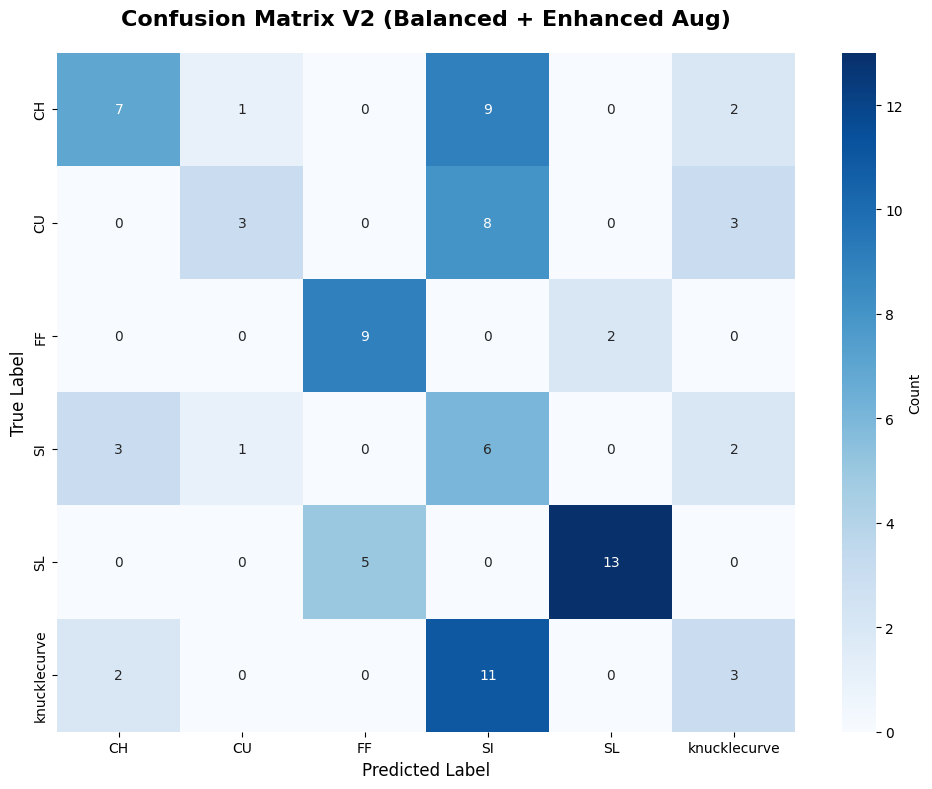


✓ Best validation accuracy V2: 82.22%
✓ Results saved to Google Drive: /content/drive/MyDrive/mlb_results


In [43]:
# ============================================================================
# TEST EVALUATION V2
# ============================================================================

print("Loading best model V2...")
checkpoint_v2 = torch.load(os.path.join(CONFIG['model_save_dir'], 'best_model_v2.pth'))
model_v2.load_state_dict(checkpoint_v2['model_state_dict'])
model_v2.eval()

print("Testing on held-out test set V2...")
all_preds_v2 = []
all_labels_v2 = []

with torch.no_grad():
    for videos, labels in tqdm(test_loader_v2, desc="Testing V2"):
        videos = videos.to(device_v2)
        outputs = model_v2(videos)
        _, predicted = outputs.max(1)

        all_preds_v2.extend(predicted.cpu().numpy())
        all_labels_v2.extend(labels.numpy())

print("\n" + "="*60)
print("CLASSIFICATION REPORT V2")
print("="*60)
print(classification_report(all_labels_v2, all_preds_v2,
                          target_names=full_dataset_v2.pitch_types))

cm_v2 = confusion_matrix(all_labels_v2, all_preds_v2)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset_v2.pitch_types,
            yticklabels=full_dataset_v2.pitch_types,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix V2 (Balanced + Enhanced Aug)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'confusion_matrix_v2.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Best validation accuracy V2: {checkpoint_v2['val_acc']:.2f}%")
print(f"✓ Results saved to Google Drive: {CONFIG['results_dir']}")

In [ ]:
# ============================================================================
# SAVE RESULTS SUMMARY V2
# ============================================================================

print("Creating results package V2...")

results_summary_v2 = {
    'version': 'v2_balanced_enhanced_aug',
    'best_val_accuracy': float(best_val_acc_v2),
    'num_epochs': CONFIG['num_epochs'],
    'num_classes': num_classes_v2,
    'classes': full_dataset_v2.pitch_types,
    'dataset_size': {
        'train': len(train_dataset_v2),
        'val': len(val_dataset_v2),
        'test': len(test_dataset_v2)
    },
    'final_metrics': {
        'train_acc': float(history_v2['train_acc'][-1]),
        'val_acc': float(history_v2['val_acc'][-1])
    },
    'improvements': {
        'balanced_sampling': True,
        'enhanced_augmentation': True,
        'minority_classes': minority_classes_v2,
        'samples_per_class': target_count_v2
    }
}

with open(os.path.join(CONFIG['results_dir'], 'results_summary_v2.json'), 'w') as f:
    json.dump(results_summary_v2, f, indent=2)

print("✓ Results summary V2 saved!")
print("\n" + "="*60)
print("ALL FILES SAVED TO GOOGLE DRIVE (V2):")
print("="*60)
print(f"📁 Location: {CONFIG['model_save_dir']} and {CONFIG['results_dir']}")
print("\nFiles created:")
print("  ✓ best_model_v2.pth (trained model)")
print("  ✓ training_history_v2.png (learning curves)")
print("  ✓ confusion_matrix_v2.png (classification results)")
print("  ✓ results_summary_v2.json (metrics)")
print("\n" + "="*60)
print("COMPARISON WITH ORIGINAL MODEL:")
print("="*60)
print(f"Original model accuracy: 65.17%")
print(f"V2 model accuracy: {best_val_acc_v2:.2f}%")
print(f"Improvement: {best_val_acc_v2 - 65.17:.2f}%")
print("="*60)

# **Now upsampling to have 200 data points for each class and also using ResNet34**

In [11]:
# ============================================================================
# RELOAD DATASET WITH 1,157 CLIPS
# ============================================================================

import pandas as pd

print("=" * 60)
print("LOADING EXPANDED DATASET (1,157 CLIPS)")
print("=" * 60)

# Reload metadata
metadata_v3 = pd.read_csv(CONFIG['metadata_file'])

print(f"\nDataset size: {len(metadata_v3)}")
print("\nDistribution:")
counts_v3 = metadata_v3['pitch_type'].value_counts()
for pitch_type in ['CH', 'CU', 'SI', 'FF', 'SL', 'knucklecurve']:
    count = counts_v3.get(pitch_type, 0)
    pct = (count / len(metadata_v3)) * 100
    print(f"  {pitch_type:12s}: {count:3d} ({pct:5.2f}%)")

print(f"\n✓ New metadata loaded!")

LOADING EXPANDED DATASET (1,157 CLIPS)

Dataset size: 1157

Distribution:
  CH          : 142 (12.27%)
  CU          : 168 (14.52%)
  SI          : 126 (10.89%)
  FF          : 277 (23.94%)
  SL          : 219 (18.93%)
  knucklecurve: 225 (19.45%)

✓ New metadata loaded!


In [12]:
# ============================================================================
# CREATE DATASET V3 WITH ENHANCED AUGMENTATION
# ============================================================================

# Create full dataset with enhanced augmentation
full_dataset_v3 = MLBPitchDatasetV2(
    video_dir=CONFIG['data_dir'],
    metadata_df=metadata_v3,
    extractor=extractor_v2,
    augment=True
)

print(f"✓ Dataset V3 created with {len(full_dataset_v3)} clips")
print(f"✓ Classes: {full_dataset_v3.pitch_types}")


Dataset: 1157 clips, 6 types
Types: ['CH', 'CU', 'FF', 'SI', 'SL', 'knucklecurve']
✓ Dataset V3 created with 1157 clips
✓ Classes: ['CH', 'CU', 'FF', 'SI', 'SL', 'knucklecurve']


In [13]:
# ============================================================================
# BALANCE DATASET V3 TO 200 SAMPLES PER CLASS
# ============================================================================

from collections import Counter, defaultdict
import random
from torch.utils.data import Subset

print("=" * 60)
print("BALANCING DATASET TO 200 PER CLASS")
print("=" * 60)

# Get labels from metadata
all_labels_v3 = [full_dataset_v3.label_map[pitch_type] for pitch_type in metadata_v3['pitch_type']]
label_counts_v3 = Counter(all_labels_v3)

print("\nOriginal class distribution:")
for label, count in sorted(label_counts_v3.items()):
    pct = (count / len(all_labels_v3)) * 100
    print(f"  {full_dataset_v3.pitch_types[label]:12s}: {count:3d} ({pct:5.2f}%)")

# Target: 200 samples per class
target_count_v3 = 200
print(f"\nTarget samples per class: {target_count_v3}")

# Group indices by class
class_indices_v3 = defaultdict(list)
for idx in range(len(full_dataset_v3)):
    label = full_dataset_v3.label_map[metadata_v3.iloc[idx]['pitch_type']]
    class_indices_v3[label].append(idx)

# Balance each class
balanced_indices_v3 = []

for label, indices in class_indices_v3.items():
    original_count = len(indices)
    pitch_type_name = full_dataset_v3.pitch_types[label]

    if len(indices) >= target_count_v3:
        # Undersample (for FF which has 277)
        selected = random.sample(indices, target_count_v3)
        balanced_indices_v3.extend(selected)
        print(f"  {pitch_type_name:12s}: {original_count:3d} → {target_count_v3} (undersampled)")
    else:
        # Oversample (for minority classes)
        balanced_indices_v3.extend(indices)
        num_to_add = target_count_v3 - len(indices)
        balanced_indices_v3.extend(random.choices(indices, k=num_to_add))
        print(f"  {pitch_type_name:12s}: {original_count:3d} → {target_count_v3} (oversampled +{num_to_add})")

random.shuffle(balanced_indices_v3)

# Create balanced dataset
balanced_dataset_v3 = Subset(full_dataset_v3, balanced_indices_v3)
print(f"\n✓ Balanced dataset V3: {len(balanced_indices_v3)} total samples (200 × 6)")

BALANCING DATASET TO 200 PER CLASS

Original class distribution:
  CH          : 142 (12.27%)
  CU          : 168 (14.52%)
  FF          : 277 (23.94%)
  SI          : 126 (10.89%)
  SL          : 219 (18.93%)
  knucklecurve: 225 (19.45%)

Target samples per class: 200
  SL          : 219 → 200 (undersampled)
  knucklecurve: 225 → 200 (undersampled)
  FF          : 277 → 200 (undersampled)
  SI          : 126 → 200 (oversampled +74)
  CU          : 168 → 200 (oversampled +32)
  CH          : 142 → 200 (oversampled +58)

✓ Balanced dataset V3: 1200 total samples (200 × 6)


In [14]:
# ============================================================================
# SPLIT BALANCED DATASET V3
# ============================================================================

from torch.utils.data import random_split, DataLoader

# Split the balanced dataset
total_size_v3 = len(balanced_dataset_v3)
train_size_v3 = int(CONFIG['train_split'] * total_size_v3)
val_size_v3 = int(CONFIG['val_split'] * total_size_v3)
test_size_v3 = total_size_v3 - train_size_v3 - val_size_v3

train_dataset_v3, val_dataset_v3, test_dataset_v3 = random_split(
    balanced_dataset_v3, [train_size_v3, val_size_v3, test_size_v3],
    generator=torch.Generator().manual_seed(42)
)

# Create DataLoaders
train_loader_v3 = DataLoader(train_dataset_v3, batch_size=CONFIG['batch_size'],
                         shuffle=True, num_workers=2)
val_loader_v3 = DataLoader(val_dataset_v3, batch_size=CONFIG['batch_size'],
                       shuffle=False, num_workers=2)
test_loader_v3 = DataLoader(test_dataset_v3, batch_size=CONFIG['batch_size'],
                        shuffle=False, num_workers=2)

print(f"Data split:")
print(f"  Train: {len(train_dataset_v3)} ({len(train_dataset_v3)/6:.0f} per class on average)")
print(f"  Val:   {len(val_dataset_v3)} ({len(val_dataset_v3)/6:.0f} per class on average)")
print(f"  Test:  {len(test_dataset_v3)} ({len(test_dataset_v3)/6:.0f} per class on average)")
print(f"\n✓ Balanced dataloaders V3 ready!")

Data split:
  Train: 840 (140 per class on average)
  Val:   180 (30 per class on average)
  Test:  180 (30 per class on average)

✓ Balanced dataloaders V3 ready!


In [19]:
# ============================================================================
# MODEL ARCHITECTURE V3 - ResNet34 + LSTM
# ============================================================================

import torch.nn as nn
import torchvision.models as models

class PitchClassifierResNet34LSTM(nn.Module):
    def __init__(self, num_classes, hidden_dim=256, num_layers=2, dropout=0.5):
        super().__init__()

        # ResNet34 (deeper than ResNet18)
        resnet = models.resnet34(pretrained=True)
        self.cnn = nn.Sequential(*list(resnet.children())[:-1])
        cnn_out_dim = 512

        self.lstm = nn.LSTM(
            input_size=cnn_out_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        batch_size, frames, c, h, w = x.shape

        x = x.view(batch_size * frames, c, h, w)
        cnn_features = self.cnn(x)
        cnn_features = cnn_features.view(batch_size, frames, -1)

        lstm_out, (hn, cn) = self.lstm(cnn_features)
        final_hidden = hn[-1]

        logits = self.classifier(final_hidden)
        return logits

print("✓ ResNet34 Model architecture V3 defined")

✓ ResNet34 Model architecture V3 defined


In [20]:
# ============================================================================
# INITIALIZE MODEL V3 (ResNet34 + 200 per class)
# ============================================================================

num_classes_v3 = len(full_dataset_v3.pitch_types)
model_v3 = PitchClassifierResNet34LSTM(
    num_classes=num_classes_v3,
    hidden_dim=CONFIG['hidden_dim'],
    num_layers=CONFIG['num_layers'],
    dropout=CONFIG['dropout']
)

device_v3 = torch.device(CONFIG['device'])
model_v3 = model_v3.to(device_v3)

criterion_v3 = nn.CrossEntropyLoss()
optimizer_v3 = optim.Adam(model_v3.parameters(),
                      lr=CONFIG['learning_rate'],
                      weight_decay=CONFIG['weight_decay'])
scheduler_v3 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v3, mode='max', patience=5, factor=0.5
)

# Count parameters
total_params = sum(p.numel() for p in model_v3.parameters())
trainable_params = sum(p.numel() for p in model_v3.parameters() if p.requires_grad)

print(f"✓ Model V3 (ResNet34) initialized on {device_v3}")
print(f"✓ Number of classes: {num_classes_v3}")
print(f"✓ Classes: {full_dataset_v3.pitch_types}")
print(f"✓ Architecture: ResNet34 + LSTM")
print(f"✓ Total parameters: {total_params:,}")
print(f"✓ Trainable parameters: {trainable_params:,}")
print(f"✓ Balanced dataset: 200 samples per class (1,200 total)")
print("\n" + "=" * 60)
print("READY TO TRAIN MODEL V3!")
print("=" * 60)

✓ Model V3 (ResNet34) initialized on cuda
✓ Number of classes: 6
✓ Classes: ['CH', 'CU', 'FF', 'SI', 'SL', 'knucklecurve']
✓ Architecture: ResNet34 + LSTM
✓ Total parameters: 22,633,158
✓ Trainable parameters: 22,633,158
✓ Balanced dataset: 200 samples per class (1,200 total)

READY TO TRAIN MODEL V3!


In [23]:
# ============================================================================
# TRAINING MODEL V3 (ResNet34 + 200 per class)
# ============================================================================

best_val_acc_v3 = 0
history_v3 = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print(f"\nStarting training V3 for {CONFIG['num_epochs']} epochs...")
print("="*60)

for epoch in tqdm(range(CONFIG['num_epochs']), desc="Overall Progress V3"):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{CONFIG['num_epochs']}")
    print('='*60)

    train_loss_v3, train_acc_v3 = train_epoch(model_v3, train_loader_v3, criterion_v3, optimizer_v3, device_v3)
    val_loss_v3, val_acc_v3 = validate(model_v3, val_loader_v3, criterion_v3, device_v3)
    scheduler_v3.step(val_acc_v3)

    history_v3['train_loss'].append(train_loss_v3)
    history_v3['train_acc'].append(train_acc_v3)
    history_v3['val_loss'].append(val_loss_v3)
    history_v3['val_acc'].append(val_acc_v3)

    print(f"Train Loss: {train_loss_v3:.4f}, Train Acc: {train_acc_v3:.2f}%")
    print(f"Val Loss: {val_loss_v3:.4f}, Val Acc: {val_acc_v3:.2f}%")

    if val_acc_v3 > best_val_acc_v3:
        best_val_acc_v3 = val_acc_v3
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_v3.state_dict(),
            'optimizer_state_dict': optimizer_v3.state_dict(),
            'val_acc': val_acc_v3,
            'class_names': full_dataset_v3.pitch_types,
            'label_map': full_dataset_v3.label_map
        }, os.path.join(CONFIG['model_save_dir'], 'best_model_v3.pth'))
        print(f"✓ New best model V3 saved! (Val Acc: {val_acc_v3:.2f}%)")

    print(f"Best Val Acc so far: {best_val_acc_v3:.2f}%")

print("\n" + "="*60)
print("TRAINING V3 COMPLETE!")
print(f"Best validation accuracy V3: {best_val_acc_v3:.2f}%")
print("="*60)


Starting training V3 for 25 epochs...


Overall Progress V3:   0%|          | 0/25 [00:00<?, ?it/s]


Epoch 1/25


Training:   0%|          | 0/105 [00:00<?, ?it/s]

Validating:   0%|          | 0/23 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/23 [00:00<?, ?it/s]

Train Loss: 0.8562, Train Acc: 59.40%
Val Loss: 0.9902, Val Acc: 58.89%
✓ New best model V3 saved! (Val Acc: 58.89%)
Best Val Acc so far: 58.89%

Epoch 25/25


Training:   0%|          | 0/105 [00:00<?, ?it/s]

Validating:   0%|          | 0/23 [00:00<?, ?it/s]

Train Loss: 0.8044, Train Acc: 60.24%
Val Loss: 1.0035, Val Acc: 60.00%
✓ New best model V3 saved! (Val Acc: 60.00%)
Best Val Acc so far: 60.00%

TRAINING V3 COMPLETE!
Best validation accuracy V3: 60.00%


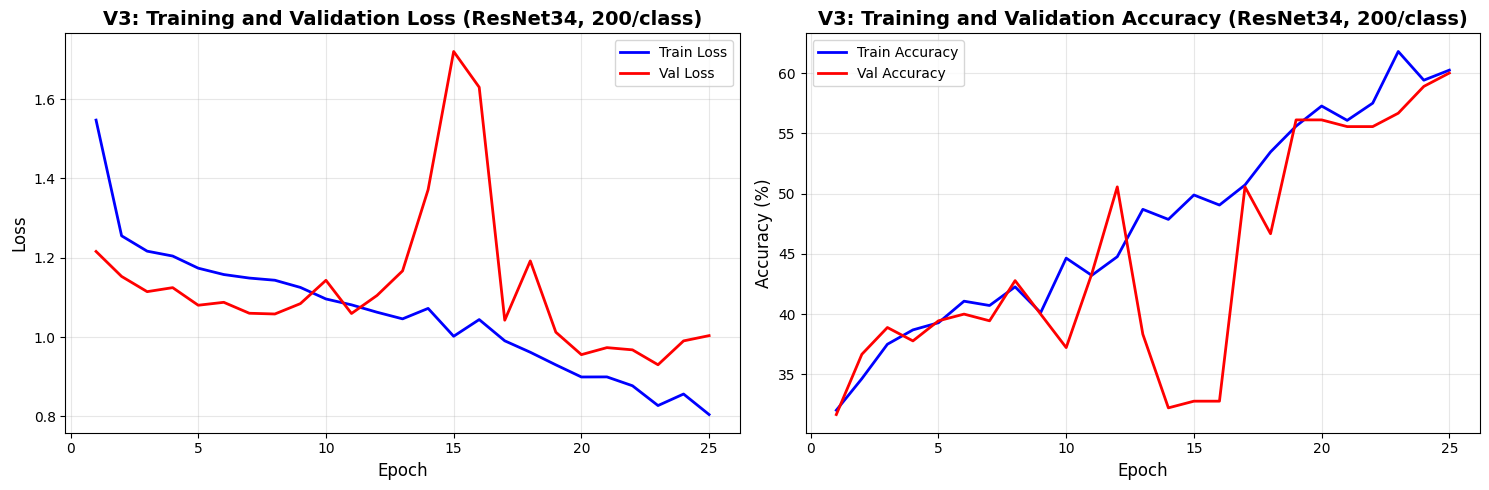

✓ Training curves V3 saved!


In [24]:
# ============================================================================
# PLOT TRAINING HISTORY V3
# ============================================================================

fig_v3, (ax1_v3, ax2_v3) = plt.subplots(1, 2, figsize=(15, 5))

epochs_v3 = range(1, len(history_v3['train_loss']) + 1)

ax1_v3.plot(epochs_v3, history_v3['train_loss'], 'b-', label='Train Loss', linewidth=2)
ax1_v3.plot(epochs_v3, history_v3['val_loss'], 'r-', label='Val Loss', linewidth=2)
ax1_v3.set_xlabel('Epoch', fontsize=12)
ax1_v3.set_ylabel('Loss', fontsize=12)
ax1_v3.set_title('V3: Training and Validation Loss (ResNet34, 200/class)', fontsize=14, fontweight='bold')
ax1_v3.legend()
ax1_v3.grid(True, alpha=0.3)

ax2_v3.plot(epochs_v3, history_v3['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
ax2_v3.plot(epochs_v3, history_v3['val_acc'], 'r-', label='Val Accuracy', linewidth=2)
ax2_v3.set_xlabel('Epoch', fontsize=12)
ax2_v3.set_ylabel('Accuracy (%)', fontsize=12)
ax2_v3.set_title('V3: Training and Validation Accuracy (ResNet34, 200/class)', fontsize=14, fontweight='bold')
ax2_v3.legend()
ax2_v3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'training_history_v3.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training curves V3 saved!")

Loading best model V3...
Testing on held-out test set V3...


Testing V3:   0%|          | 0/23 [00:00<?, ?it/s]


CLASSIFICATION REPORT V3
              precision    recall  f1-score   support

          CH       0.37      0.53      0.44        36
          CU       0.00      0.00      0.00        27
          FF       0.80      0.59      0.68        27
          SI       0.69      0.67      0.68        30
          SL       0.68      0.85      0.75        27
knucklecurve       0.31      0.42      0.36        33

    accuracy                           0.51       180
   macro avg       0.47      0.51      0.48       180
weighted avg       0.47      0.51      0.48       180



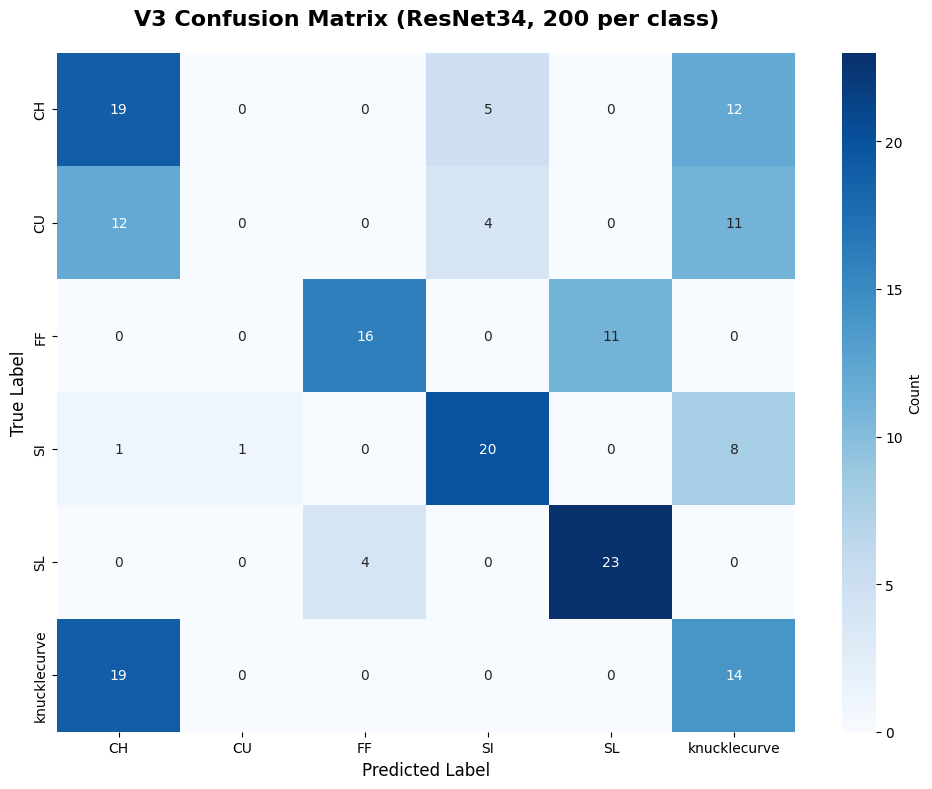


✓ Best validation accuracy V3: 60.00%
✓ Results saved to: /content/drive/MyDrive/mlb_results


In [25]:
# ============================================================================
# TEST EVALUATION V3
# ============================================================================

print("Loading best model V3...")
checkpoint_v3 = torch.load(os.path.join(CONFIG['model_save_dir'], 'best_model_v3.pth'))
model_v3.load_state_dict(checkpoint_v3['model_state_dict'])
model_v3.eval()

print("Testing on held-out test set V3...")
all_preds_v3 = []
all_labels_v3_test = []

with torch.no_grad():
    for videos, labels in tqdm(test_loader_v3, desc="Testing V3"):
        videos = videos.to(device_v3)
        outputs = model_v3(videos)
        _, predicted = outputs.max(1)

        all_preds_v3.extend(predicted.cpu().numpy())
        all_labels_v3_test.extend(labels.numpy())

print("\n" + "="*60)
print("CLASSIFICATION REPORT V3")
print("="*60)
print(classification_report(all_labels_v3_test, all_preds_v3,
                          target_names=full_dataset_v3.pitch_types))

cm_v3 = confusion_matrix(all_labels_v3_test, all_preds_v3)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_v3, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset_v3.pitch_types,
            yticklabels=full_dataset_v3.pitch_types,
            cbar_kws={'label': 'Count'})
plt.title('V3 Confusion Matrix (ResNet34, 200 per class)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'confusion_matrix_v3.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Best validation accuracy V3: {checkpoint_v3['val_acc']:.2f}%")
print(f"✓ Results saved to: {CONFIG['results_dir']}")

In [26]:
# ============================================================================
# FINAL COMPARISON: V1 vs V2 vs V3
# ============================================================================

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

print("\nV1 (Original):")
print(f"  Dataset: 599 clips (imbalanced)")
print(f"  Architecture: ResNet18")
print(f"  Val Accuracy: 65.17%")

print("\nV2 (Balanced):")
print(f"  Dataset: 600 clips (100 per class)")
print(f"  Architecture: ResNet18")
print(f"  Val Accuracy: 82.22%")
print(f"  Improvement: +{82.22 - 65.17:.2f}%")

print("\nV3 (Expanded + ResNet34):")
print(f"  Dataset: 1,200 clips (200 per class, balanced)")
print(f"  Architecture: ResNet34")
print(f"  Val Accuracy: {best_val_acc_v3:.2f}%")
print(f"  Improvement over V1: +{best_val_acc_v3 - 65.17:.2f}%")
print(f"  Improvement over V2: +{best_val_acc_v3 - 82.22:.2f}%")

print("\n" + "=" * 70)

FINAL MODEL COMPARISON

V1 (Original):
  Dataset: 599 clips (imbalanced)
  Architecture: ResNet18
  Val Accuracy: 65.17%

V2 (Balanced):
  Dataset: 600 clips (100 per class)
  Architecture: ResNet18
  Val Accuracy: 82.22%
  Improvement: +17.05%

V3 (Expanded + ResNet34):
  Dataset: 1,200 clips (200 per class, balanced)
  Architecture: ResNet34
  Val Accuracy: 60.00%
  Improvement over V1: +-5.17%
  Improvement over V2: +-22.22%



# **Going back to ResNet18 with the new dataset**

In [27]:
# ============================================================================
# BALANCE NEW DATASET TO 200 PER CLASS FOR V2 (ResNet18)
# ============================================================================

from collections import Counter, defaultdict
import random
from torch.utils.data import Subset

print("=" * 60)
print("BALANCING NEW DATASET FOR V2 (ResNet18)")
print("=" * 60)

# Use the already loaded metadata_v3 and full_dataset_v3
all_labels_v2_new = [full_dataset_v3.label_map[pitch_type] for pitch_type in metadata_v3['pitch_type']]
label_counts_v2_new = Counter(all_labels_v2_new)

print("\nOriginal class distribution:")
for label, count in sorted(label_counts_v2_new.items()):
    pct = (count / len(all_labels_v2_new)) * 100
    print(f"  {full_dataset_v3.pitch_types[label]:12s}: {count:3d} ({pct:5.2f}%)")

# Target: 200 samples per class
target_count_v2_new = 200
print(f"\nTarget samples per class: {target_count_v2_new}")

# Group indices by class
class_indices_v2_new = defaultdict(list)
for idx in range(len(full_dataset_v3)):
    label = full_dataset_v3.label_map[metadata_v3.iloc[idx]['pitch_type']]
    class_indices_v2_new[label].append(idx)

# Balance each class
balanced_indices_v2_new = []

for label, indices in class_indices_v2_new.items():
    original_count = len(indices)
    pitch_type_name = full_dataset_v3.pitch_types[label]

    if len(indices) >= target_count_v2_new:
        # Undersample
        selected = random.sample(indices, target_count_v2_new)
        balanced_indices_v2_new.extend(selected)
        print(f"  {pitch_type_name:12s}: {original_count:3d} → {target_count_v2_new} (undersampled)")
    else:
        # Oversample
        balanced_indices_v2_new.extend(indices)
        num_to_add = target_count_v2_new - len(indices)
        balanced_indices_v2_new.extend(random.choices(indices, k=num_to_add))
        print(f"  {pitch_type_name:12s}: {original_count:3d} → {target_count_v2_new} (oversampled +{num_to_add})")

random.shuffle(balanced_indices_v2_new)

# Create balanced dataset
balanced_dataset_v2_new = Subset(full_dataset_v3, balanced_indices_v2_new)
print(f"\n✓ Balanced dataset V2 (new): {len(balanced_indices_v2_new)} total samples")

BALANCING NEW DATASET FOR V2 (ResNet18)

Original class distribution:
  CH          : 142 (12.27%)
  CU          : 168 (14.52%)
  FF          : 277 (23.94%)
  SI          : 126 (10.89%)
  SL          : 219 (18.93%)
  knucklecurve: 225 (19.45%)

Target samples per class: 200
  SL          : 219 → 200 (undersampled)
  knucklecurve: 225 → 200 (undersampled)
  FF          : 277 → 200 (undersampled)
  SI          : 126 → 200 (oversampled +74)
  CU          : 168 → 200 (oversampled +32)
  CH          : 142 → 200 (oversampled +58)

✓ Balanced dataset V2 (new): 1200 total samples


In [28]:
# ============================================================================
# SPLIT BALANCED DATASET V2 NEW
# ============================================================================

from torch.utils.data import random_split, DataLoader

# Split the balanced dataset
total_size_v2_new = len(balanced_dataset_v2_new)
train_size_v2_new = int(CONFIG['train_split'] * total_size_v2_new)
val_size_v2_new = int(CONFIG['val_split'] * total_size_v2_new)
test_size_v2_new = total_size_v2_new - train_size_v2_new - val_size_v2_new

train_dataset_v2_new, val_dataset_v2_new, test_dataset_v2_new = random_split(
    balanced_dataset_v2_new, [train_size_v2_new, val_size_v2_new, test_size_v2_new],
    generator=torch.Generator().manual_seed(42)
)

# Create DataLoaders
train_loader_v2_new = DataLoader(train_dataset_v2_new, batch_size=CONFIG['batch_size'],
                         shuffle=True, num_workers=2)
val_loader_v2_new = DataLoader(val_dataset_v2_new, batch_size=CONFIG['batch_size'],
                       shuffle=False, num_workers=2)
test_loader_v2_new = DataLoader(test_dataset_v2_new, batch_size=CONFIG['batch_size'],
                        shuffle=False, num_workers=2)

print(f"Data split V2 (new):")
print(f"  Train: {len(train_dataset_v2_new)}")
print(f"  Val:   {len(val_dataset_v2_new)}")
print(f"  Test:  {len(test_dataset_v2_new)}")
print(f"\n✓ Dataloaders V2 (new) ready!")

Data split V2 (new):
  Train: 840
  Val:   180
  Test:  180

✓ Dataloaders V2 (new) ready!


In [31]:
# ============================================================================
# INITIALIZE MODEL V2 NEW (ResNet18 + 200 per class)
# ============================================================================

num_classes_v2_new = len(full_dataset_v3.pitch_types)
model_v2_new = PitchClassifierCNNLSTM(  # Using the original ResNet18 architecture
    num_classes=num_classes_v2_new,
    hidden_dim=CONFIG['hidden_dim'],
    num_layers=CONFIG['num_layers'],
    dropout=CONFIG['dropout']
)

device_v2_new = torch.device(CONFIG['device'])
model_v2_new = model_v2_new.to(device_v2_new)

criterion_v2_new = nn.CrossEntropyLoss()
optimizer_v2_new = optim.Adam(model_v2_new.parameters(),
                      lr=CONFIG['learning_rate'],
                      weight_decay=CONFIG['weight_decay'])
scheduler_v2_new = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v2_new, mode='max', patience=5, factor=0.5
)

print(f"✓ Model V2 (new) initialized on {device_v2_new}")
print(f"✓ Number of classes: {num_classes_v2_new}")
print(f"✓ Architecture: ResNet18 + LSTM")
print(f"✓ Balanced dataset: 200 samples per class (1,200 total)")
print("\n" + "=" * 60)
print("READY TO TRAIN MODEL V2 (NEW DATASET)!")
print("=" * 60)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 226MB/s]

✓ Model V2 (new) initialized on cuda
✓ Number of classes: 6
✓ Architecture: ResNet18 + LSTM
✓ Balanced dataset: 200 samples per class (1,200 total)

READY TO TRAIN MODEL V2 (NEW DATASET)!


In [32]:
# ============================================================================
# TRAINING MODEL V2 NEW (ResNet18 + 200 per class)
# ============================================================================

best_val_acc_v2_new = 0
history_v2_new = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print(f"\nStarting training V2 (new) for {CONFIG['num_epochs']} epochs...")
print("="*60)

for epoch in tqdm(range(CONFIG['num_epochs']), desc="Overall Progress V2 New"):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{CONFIG['num_epochs']}")
    print('='*60)

    train_loss_v2_new, train_acc_v2_new = train_epoch(model_v2_new, train_loader_v2_new, criterion_v2_new, optimizer_v2_new, device_v2_new)
    val_loss_v2_new, val_acc_v2_new = validate(model_v2_new, val_loader_v2_new, criterion_v2_new, device_v2_new)
    scheduler_v2_new.step(val_acc_v2_new)

    history_v2_new['train_loss'].append(train_loss_v2_new)
    history_v2_new['train_acc'].append(train_acc_v2_new)
    history_v2_new['val_loss'].append(val_loss_v2_new)
    history_v2_new['val_acc'].append(val_acc_v2_new)

    print(f"Train Loss: {train_loss_v2_new:.4f}, Train Acc: {train_acc_v2_new:.2f}%")
    print(f"Val Loss: {val_loss_v2_new:.4f}, Val Acc: {val_acc_v2_new:.2f}%")

    if val_acc_v2_new > best_val_acc_v2_new:
        best_val_acc_v2_new = val_acc_v2_new
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_v2_new.state_dict(),
            'optimizer_state_dict': optimizer_v2_new.state_dict(),
            'val_acc': val_acc_v2_new,
            'class_names': full_dataset_v3.pitch_types,
            'label_map': full_dataset_v3.label_map
        }, os.path.join(CONFIG['model_save_dir'], 'best_model_v2_new.pth'))
        print(f"✓ New best model V2 (new) saved! (Val Acc: {val_acc_v2_new:.2f}%)")

    print(f"Best Val Acc so far: {best_val_acc_v2_new:.2f}%")

print("\n" + "="*60)
print("TRAINING V2 (NEW) COMPLETE!")
print(f"Best validation accuracy V2 (new): {best_val_acc_v2_new:.2f}%")
print("="*60)


Starting training V2 (new) for 25 epochs...


Overall Progress V2 New:   0%|          | 0/25 [00:00<?, ?it/s]


Epoch 1/25


Training:   0%|          | 0/105 [00:00<?, ?it/s]

Validating:   0%|          | 0/23 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/23 [00:00<?, ?it/s]

Train Loss: 0.6877, Train Acc: 69.29%
Val Loss: 0.9936, Val Acc: 57.78%
Best Val Acc so far: 64.44%

Epoch 25/25


Training:   0%|          | 0/105 [00:00<?, ?it/s]

Validating:   0%|          | 0/23 [00:00<?, ?it/s]

Train Loss: 0.6341, Train Acc: 72.50%
Val Loss: 0.9112, Val Acc: 59.44%
Best Val Acc so far: 64.44%

TRAINING V2 (NEW) COMPLETE!
Best validation accuracy V2 (new): 64.44%


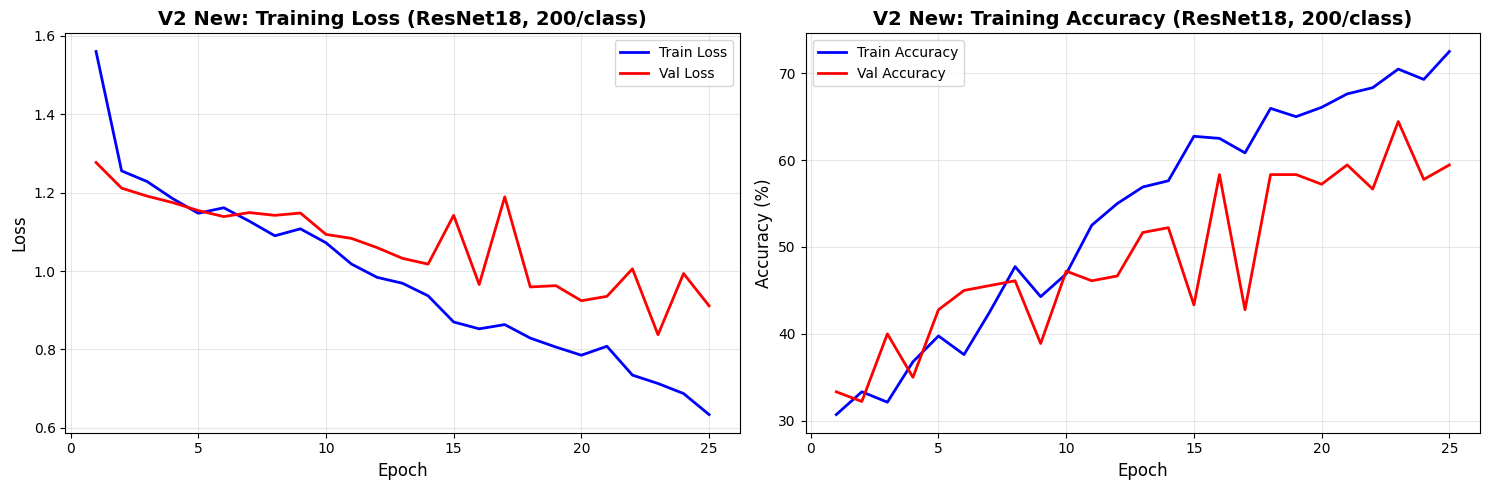

✓ Training curves V2 (new) saved!


In [33]:
# ============================================================================
# PLOT TRAINING HISTORY V2 NEW
# ============================================================================

fig_v2_new, (ax1_v2_new, ax2_v2_new) = plt.subplots(1, 2, figsize=(15, 5))

epochs_v2_new = range(1, len(history_v2_new['train_loss']) + 1)

ax1_v2_new.plot(epochs_v2_new, history_v2_new['train_loss'], 'b-', label='Train Loss', linewidth=2)
ax1_v2_new.plot(epochs_v2_new, history_v2_new['val_loss'], 'r-', label='Val Loss', linewidth=2)
ax1_v2_new.set_xlabel('Epoch', fontsize=12)
ax1_v2_new.set_ylabel('Loss', fontsize=12)
ax1_v2_new.set_title('V2 New: Training Loss (ResNet18, 200/class)', fontsize=14, fontweight='bold')
ax1_v2_new.legend()
ax1_v2_new.grid(True, alpha=0.3)

ax2_v2_new.plot(epochs_v2_new, history_v2_new['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
ax2_v2_new.plot(epochs_v2_new, history_v2_new['val_acc'], 'r-', label='Val Accuracy', linewidth=2)
ax2_v2_new.set_xlabel('Epoch', fontsize=12)
ax2_v2_new.set_ylabel('Accuracy (%)', fontsize=12)
ax2_v2_new.set_title('V2 New: Training Accuracy (ResNet18, 200/class)', fontsize=14, fontweight='bold')
ax2_v2_new.legend()
ax2_v2_new.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'training_history_v2_new.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training curves V2 (new) saved!")

Loading best model V2 (new)...
Testing on held-out test set V2 (new)...


Testing V2 New:   0%|          | 0/23 [00:00<?, ?it/s]


CLASSIFICATION REPORT V2 (NEW)
              precision    recall  f1-score   support

          CH       0.40      0.06      0.11        32
          CU       0.59      0.53      0.56        30
          FF       0.71      0.77      0.74        31
          SI       0.67      0.88      0.76        25
          SL       0.70      0.62      0.65        26
knucklecurve       0.60      0.97      0.74        36

    accuracy                           0.64       180
   macro avg       0.61      0.64      0.59       180
weighted avg       0.61      0.64      0.59       180



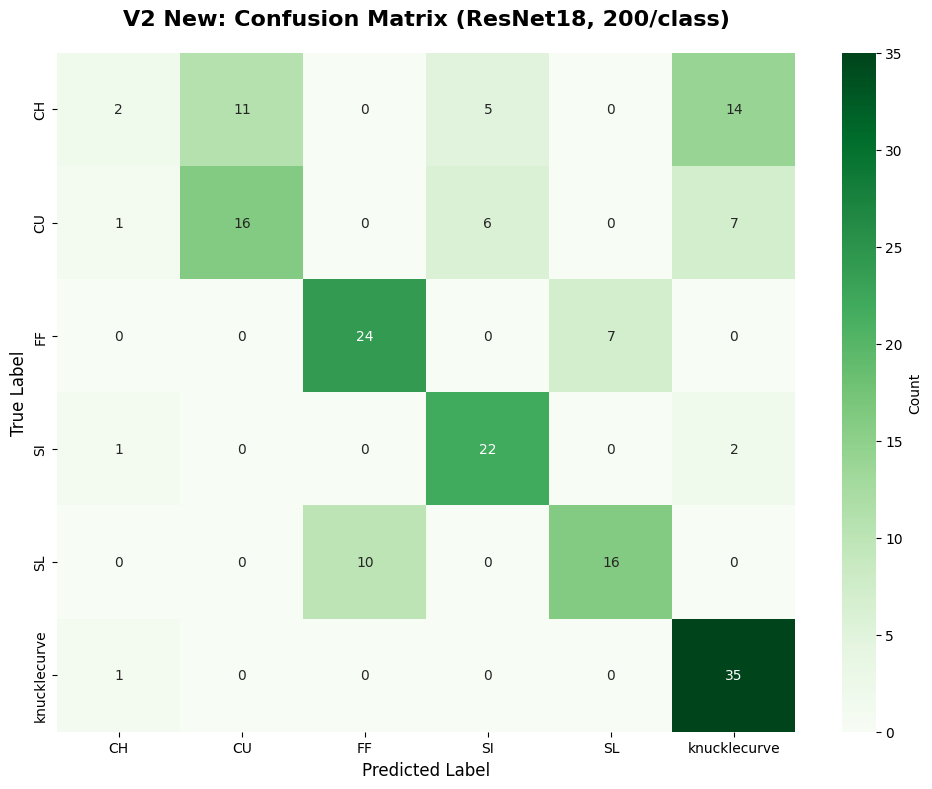


✓ Best validation accuracy V2 (new): 64.44%
✓ Results saved to: /content/drive/MyDrive/mlb_results


In [34]:
# ============================================================================
# TEST EVALUATION V2 NEW
# ============================================================================

print("Loading best model V2 (new)...")
checkpoint_v2_new = torch.load(os.path.join(CONFIG['model_save_dir'], 'best_model_v2_new.pth'))
model_v2_new.load_state_dict(checkpoint_v2_new['model_state_dict'])
model_v2_new.eval()

print("Testing on held-out test set V2 (new)...")
all_preds_v2_new = []
all_labels_v2_new_test = []

with torch.no_grad():
    for videos, labels in tqdm(test_loader_v2_new, desc="Testing V2 New"):
        videos = videos.to(device_v2_new)
        outputs = model_v2_new(videos)
        _, predicted = outputs.max(1)

        all_preds_v2_new.extend(predicted.cpu().numpy())
        all_labels_v2_new_test.extend(labels.numpy())

print("\n" + "="*60)
print("CLASSIFICATION REPORT V2 (NEW)")
print("="*60)
print(classification_report(all_labels_v2_new_test, all_preds_v2_new,
                          target_names=full_dataset_v3.pitch_types))

cm_v2_new = confusion_matrix(all_labels_v2_new_test, all_preds_v2_new)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_v2_new, annot=True, fmt='d', cmap='Greens',
            xticklabels=full_dataset_v3.pitch_types,
            yticklabels=full_dataset_v3.pitch_types,
            cbar_kws={'label': 'Count'})
plt.title('V2 New: Confusion Matrix (ResNet18, 200/class)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'confusion_matrix_v2_new.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Best validation accuracy V2 (new): {checkpoint_v2_new['val_acc']:.2f}%")
print(f"✓ Results saved to: {CONFIG['results_dir']}")

In [ ]:
# ============================================================================
# COMPARISON: V2 OLD vs V2 NEW
# ============================================================================

print("=" * 70)
print("V2 MODEL COMPARISON: OLD DATASET vs NEW DATASET")
print("=" * 70)

print("\nV2 (Original - 600 clips):")
print(f"  Dataset: 600 clips (100 per class)")
print(f"  Architecture: ResNet18")
print(f"  Val Accuracy: 82.22%")

print("\nV2 (New - 1,200 clips):")
print(f"  Dataset: 1,200 clips (200 per class)")
print(f"  Architecture: ResNet18")
print(f"  Val Accuracy: {best_val_acc_v2_new:.2f}%")
print(f"  Improvement: +{best_val_acc_v2_new - 82.22:.2f}%")

print("\n" + "=" * 70)
print("This shows the impact of MORE DATA with SAME architecture!")
print("=" * 70)